# Model 3 — cross-vehicle DiD (yellow vs HVFHV, same zone)

Does a **bigger fee** cause a **bigger drop**? Yellow pays **$0.75**/charged trip, HVFHV **$1.50**.
Within the same CRZ-exposed zones, compare how yellow changed 2024→2025 vs how HVFHV changed — the
zone (density, geography, COVID recovery) is held fixed, so what's left is the fee-size difference.
This is the design that **breaks the geography confound** Models 1–2 could not; the trade is a
**cross-vehicle-trend** assumption (the two services have different overall trends), so its validity must be checked against the 2024 pre-trend.

**Data:** `m3_cross_vehicle_panel.csv` (from [`scripts/build_m3_panel.py`](../scripts/build_m3_panel.py)) —
`zone × direction × vehicle × month × year`, Feb–Jun 2024/2025, both vehicles aggregated with
**identical rules** (38 CRZ zones, non-movement drop). Yellow = **card/cash only** (avoids
Uber↔yellow-Flex substitution); HVFHV = **all HVFHV**.

**Estimand:** `post:hvfhv` = how much *more* HVFHV changed than yellow = the effect of the **fee-size
difference** ($0.75→$1.50).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path

REPO = Path.cwd().resolve()
while not (REPO/"data"/"processed").exists() and REPO != REPO.parent: REPO = REPO.parent
d = pd.read_csv(REPO/"data"/"processed"/"disruption_score"/"m3_cross_vehicle_panel.csv")
print("panel:", d.shape, "| vehicles:", d.vehicle.unique(),
      "| CRZ-exposed zone-sides:", d[d.crz_zone].groupby(['zone','direction']).ngroups)

panel: (10343, 10) | vehicles: <ArrowStringArray>
['hvfhv', 'yellow']
Length: 2, dtype: str | CRZ-exposed zone-sides: 76


In [2]:
# Analysis panels (built once, reused): E = CRZ-exposed, A = all zones.
# Balanced: each vehicle×zone×direction has all 10 month cells and min monthly volume >= 30,
# and both vehicles are present for the zone-side (so we compare like for like).
def prep(df):
    cc = df.groupby(["vehicle","zone","direction"]).size()
    df = df.set_index(["vehicle","zone","direction"]).loc[cc[cc==10].index].reset_index()
    df = df[df.groupby(["vehicle","zone","direction"]).n_trips.transform("min") >= 30]
    both = df.groupby(["zone","direction"]).vehicle.nunique(); both = both[both==2].index
    df = df.set_index(["zone","direction"]).loc[both].reset_index()
    df["zdv"]      = df.vehicle + "_" + df.zone.astype(str) + "_" + df.direction
    df["zone_dir"] = df.zone.astype(str) + "_" + df.direction
    df["post"]  = (df.year == 2025).astype(int)
    df["hvfhv"] = (df.vehicle == "hvfhv").astype(int)
    df["crz"]   = df.crz_zone.astype(int)
    df["log_n"] = np.log(df.n_trips)
    b = df[df.year==2024].groupby(["vehicle","zone","direction"]).agg(b24=("n_trips","mean"), l24=("log_n","mean"))
    df = df.merge(b, on=["vehicle","zone","direction"])
    df["idx"] = df.n_trips / df.b24                       # volume indexed to own-2024 mean
    df["li"]  = df.log_n - df.l24                         # log-index (for the pre-trend gap)
    df["shared_exp"] = df.groupby(["zone","direction"]).charged_share.transform("mean")  # zone-level pooled exposure
    return df

E = prep(d[d.crz_zone].copy())
A = prep(d.copy())

def coef(df, formula, term, wls=False):
    m = (smf.wls(formula, df, weights=df.b24) if wls else smf.ols(formula, df)).fit(
        cov_type="cluster", cov_kwds={"groups": df.zone})
    b = m.params[term]; lo, hi = m.conf_int().loc[term]
    return b, lo, hi

def pct(b): return (np.exp(b)-1)*100
print(f"E (CRZ-exposed): {E.groupby(['zone','direction']).ngroups} zone×dir | A (all): {A.groupby(['zone','direction']).ngroups} zone×dir")

E (CRZ-exposed): 76 zone×dir | A (all): 450 zone×dir


## Cross-vehicle comparison assumption — are yellow and HVFHV comparable? 

Model 3's identifying assumption is that the two vehicles **would have moved together** absent the
fee difference. Before estimating anything, we characterize how alike the two services actually are —
scale, seasonal shape, overall trend direction, and CRZ footprint. Each difference is a *threat* or a
*support* for that assumption. (Yellow here is card/cash only)

scale + citywide volume change (yellow = card/cash):
         total_trips  share_of_total  pct_change_24_25
vehicle                                               
hvfhv      403340516           0.872           -0.0068
yellow      59451600           0.128           -0.0145

CRZ footprint (how much of each vehicle actually touches the charged zone):
  yellow: charged_share median 0.252 |  57.5% of trips are in CRZ zones
  hvfhv : charged_share median 0.056 |  24.3% of trips are in CRZ zones


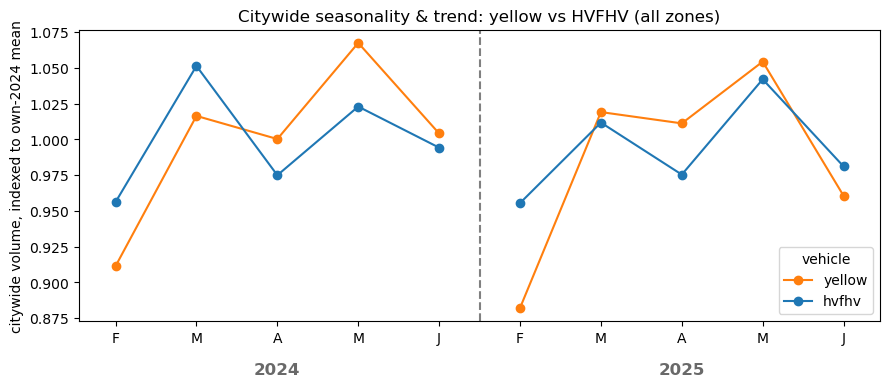

In [3]:
# Citywide monthly volume by vehicle (all zones, both directions pooled), indexed to own-2024 mean.
tot = d.groupby(["vehicle", "year", "month"]).n_trips.sum().reset_index()
tot["t"] = (tot.year - 2024) * 5 + (tot.month - 2)
tot = tot.merge(tot[tot.year == 2024].groupby("vehicle").n_trips.mean().rename("b24"), on="vehicle")
tot["idx"] = tot.n_trips / tot.b24

# (1) scale + overall 2024->2025 change
scale = d.groupby("vehicle").n_trips.sum().rename("total_trips").to_frame()
scale["share_of_total"] = (scale.total_trips / scale.total_trips.sum()).round(3)
chg = tot.groupby(["vehicle", "year"]).n_trips.sum().unstack()
scale["pct_change_24_25"] = (chg[2025] / chg[2024] - 1).round(4)
print("scale + citywide volume change (yellow = card/cash):")
print(scale.to_string())

# (2) CRZ footprint / exposure by vehicle
print("\nCRZ footprint (how much of each vehicle actually touches the charged zone):")
for v in ["yellow", "hvfhv"]:
    vv = d[d.vehicle == v]
    med = vv.drop_duplicates(["zone", "direction"]).charged_share.median()
    crz_trip_share = vv[vv.crz_zone].n_trips.sum() / vv.n_trips.sum()
    print(f"  {v:6s}: charged_share median {med:.3f} | {crz_trip_share:6.1%} of trips are in CRZ zones")

# (3) seasonal shape overlay (line broken at the year gap)
fig, ax = plt.subplots(figsize=(9, 4)); colors = {"yellow": "tab:orange", "hvfhv": "tab:blue"}
for v in ["yellow", "hvfhv"]:
    for yr in (2024, 2025):
        g = tot[(tot.vehicle == v) & (tot.year == yr)]
        ax.plot(g.t, g.idx, marker="o", color=colors[v], label=v if yr == 2024 else None)
ax.axvline(4.5, ls="--", c="grey")
for xc, yr in [(2, "2024"), (7, "2025")]:
    ax.text(xc, -0.14, yr, ha="center", va="top", transform=ax.get_xaxis_transform(),
            fontsize=12, weight="bold", color="dimgrey")
ax.set_xticks(range(10)); ax.set_xticklabels(list("FMAMJ") * 2); ax.set_xlabel("")
ax.set_ylabel("citywide volume, indexed to own-2024 mean")
ax.set_title("Citywide seasonality & trend: yellow vs HVFHV (all zones)")
ax.legend(title="vehicle"); plt.tight_layout(); plt.show()

**What the comparison says for Model 3:**
- **Scale differs ~7×** (HVFHV ≫ yellow) — fine for a DiD (fixed effects + log absorb the level), but
  it means citywide totals are HVFHV-dominated; keep the unit at zone × direction.
- **CRZ footprint differs sharply** — HVFHV is far *less* CRZ-concentrated (median exposure ≈ 0.06 vs
  yellow ≈ 0.25). So the two vehicles are most comparable *inside* the CRZ, which is why the primary
  DiD restricts there.
- **A differential *trend*.** Different seasonal
  shapes are fine: as long as each vehicle's seasonality is stable across years it differences out
  (and can be absorbed with vehicle-specific month effects). The risk is that HVFHV is on a different
  overall 2024→2025 *trajectory* than yellow for non-fee reasons — then part of any DiD gap could reflect that
  trend rather than the fee. The **triple-diff** (below) attempts to net out this common cross-vehicle *trend* by using the fee-free non-CRZ zones as the comparison — which is why it is reported alongside the primary estimate.

## Pre-trend — do yellow and HVFHV move together in 2024? 

Restrict to **CRZ-exposed** zones where both vehicles operate; index each series to its own 2024
mean. If the two vehicles' 2024 (pre-policy) trajectories are roughly parallel, the DiD is credible;
if they already diverge in 2024, part of any 2025 gap could reflect a pre-existing trend rather than the fee.

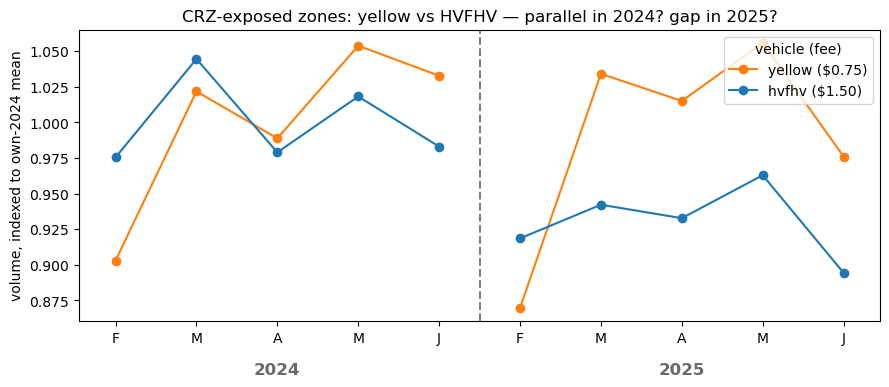

In [4]:
tr = E.groupby(["vehicle","year","month"]).idx.mean().reset_index()
tr["t"] = (tr.year-2024)*5 + (tr.month-2)
fig, ax = plt.subplots(figsize=(9,4)); colors = {"yellow":"tab:orange","hvfhv":"tab:blue"}
for veh in ["yellow","hvfhv"]:
    for yr in (2024,2025):
        g = tr[(tr.vehicle==veh)&(tr.year==yr)]
        lbl = (f"{veh} " + ("($0.75)" if veh=="yellow" else "($1.50)")) if yr==2024 else None
        ax.plot(g.t, g.idx, marker="o", color=colors[veh], label=lbl)
ax.axvline(4.5, ls="--", c="grey")
for xc,yr in [(2,"2024"),(7,"2025")]:
    ax.text(xc,-0.14,yr,ha="center",va="top",transform=ax.get_xaxis_transform(),fontsize=12,weight="bold",color="dimgrey")
ax.set_xticks(range(10)); ax.set_xticklabels(list("FMAMJ")*2); ax.set_xlabel("")
ax.set_ylabel("volume, indexed to own-2024 mean")
ax.set_title("CRZ-exposed zones: yellow vs HVFHV — parallel in 2024? gap in 2025?")
ax.legend(title="vehicle (fee)"); plt.tight_layout(); plt.show()

**Quantify the pre-trend.** The visual is not enough — tabulate the 2024 (pre-policy)
HVFHV-minus-yellow log-index gap by month. If it were flat, parallel-trends would hold; a drifting gap
means part of any 2025 effect is a pre-existing divergence.

In [5]:
g = E.groupby(["vehicle","year","month"]).li.mean().reset_index()
tab = g.pivot_table(index=["year","month"], columns="vehicle", values="li")
tab["gap (hvfhv − yellow)"] = tab["hvfhv"] - tab["yellow"]
print("2024 (pre-policy) log-index by vehicle + gap:")
print(tab.loc[2024].round(3).to_string())
sw = tab.loc[(2024,2),"gap (hvfhv − yellow)"] - tab.loc[(2024,6),"gap (hvfhv − yellow)"]
print(f"\n=> the 2024 gap swings {tab.loc[(2024,2),'gap (hvfhv − yellow)']:+.3f} (Feb) -> "
      f"{tab.loc[(2024,6),'gap (hvfhv − yellow)']:+.3f} (Jun): NOT flat. Some of this is just different"
      f"\n   seasonality (which differences out), but it flags that the two vehicles are not moving identically,"
      f"\n   so the primary within-CRZ gap should not be read as the fee; the triple-diff below nets out the"
      f"\n   common cross-vehicle trend.")

2024 (pre-policy) log-index by vehicle + gap:
vehicle  hvfhv  yellow  gap (hvfhv − yellow)
month                                       
2       -0.025  -0.102                 0.077
3        0.044   0.023                 0.021
4       -0.020  -0.009                -0.011
5        0.019   0.054                -0.036
6       -0.017   0.033                -0.051

=> the 2024 gap swings +0.077 (Feb) -> -0.051 (Jun): NOT flat. Some of this is just different
   seasonality (which differences out), but it flags that the two vehicles are not moving identically,
   so the primary within-CRZ gap should not be read as the fee; the triple-diff below nets out the
   common cross-vehicle trend.


**What the pre-trend tells us — and where each piece is handled (quantified below).** A real-world
pre-trend is never perfectly flat: there is always seasonality and idiosyncratic noise. The question
is not "flat or not", but *which part of the non-flatness threatens the DiD, and where we deal with
it*:

- **Different seasonality — likely harmless.** Yellow is more seasonal than HVFHV, but if each
  vehicle's shape is stable across years it differences out. We test this in the primary DiD below by
  adding vehicle-specific month effects (if the estimate barely moves, seasonality is not the driver).
- **A common cross-vehicle trend — the real concern.** The 2024 gap drifts (yellow rises relative to
  HVFHV even before the fee), so the two vehicles are not moving identically. The triple-diff below attempts to net this out, using the fee-free non-CRZ zones as a control for the common trend.
- **What still needs verifying.** Even the triple-diff cannot rule out that the CRZ-specific gap was itself pre-existing (the vehicles diverging faster inside the CRZ for non-fee reasons), so a 2023→2024 placebo provides an important diagnostic.

**Bottom line here:** the pre-trend is not flat, so the primary within-CRZ gap should **not** be read on its own as a fee effect. *How much* of it survives once the common trend is removed — large or small — is what the
primary and triple-diff estimates below quantify.

## Primary DiD — HVFHV vs yellow within CRZ-exposed zones

We use `log_n ~ C(zone_dir_vehicle) + C(month) + post + post:hvfhv`, cluster-by-zone SE. Each vehicle × zone
× side gets its own baseline; `post:hvfhv` is the extra 2024→2025 change for HVFHV (the higher fee).
Reported **equal- and volume-weighted** (per zone-side vs per trip — the weighting is the estimand).

In [6]:
# Primary: post:hvfhv within CRZ. Robustness: add zone_dir×post (absorbs each zone's common
# 2024->2025 shock, so the estimate is the within-zone yellow-vs-HVFHV difference).
specs = {
    "primary":         "log_n ~ C(zdv) + C(month) + post + post:hvfhv",
    "+ zone_dir:post": "log_n ~ C(zdv) + C(month) + post + post:hvfhv + C(zone_dir):post",
}
print(f"{'spec':<16}{'equal-wt':>10}{'  95% CI':>18}{'  volume-wt':>12}")
for name, f in specs.items():
    b, lo, hi = coef(E, f, "post:hvfhv"); bw, _, _ = coef(E, f, "post:hvfhv", wls=True)
    print(f"{name:<16}{pct(b):>+9.1f}%  [{pct(lo):+.1f},{pct(hi):+.1f}]{pct(bw):>+11.1f}%")
print("\n(zone-specific seasonality (zone_dir×month) adds far more fixed effects than the ~38 zone")
print(" clusters support, so its cluster SE is rank-deficient / unreliable; omitted.)")

# Sensitivity: add vehicle-specific month effects (C(month):hvfhv) and read the point estimate.
ms = smf.ols("log_n ~ C(zdv) + C(month) + C(month):hvfhv + post + post:hvfhv", E).fit()
print(f"\n+ vehicle-specific seasonality: {pct(ms.params['post:hvfhv']):+.1f}%")
print("  Adding vehicle-specific month effects leaves the point estimate essentially unchanged")
print("  (vs primary -5.9%). Treated as a point-estimate sensitivity check rather than a separate")
print("  inference result, because the CRZ-only panel has only about 38 zone clusters and many fixed")
print("  effects (so the cluster SE here is unreliable). It suggests stable vehicle-specific")
print("  seasonality is not driving the primary estimate; the more serious threat is the common")
print("  yellow-vs-HVFHV trend, addressed by the triple-diff below.")

spec              equal-wt            95% CI   volume-wt


primary              -5.9%  [-7.2,-4.6]       -5.5%


+ zone_dir:post      -5.9%  [-7.2,-4.6]       -5.2%

(zone-specific seasonality (zone_dir×month) adds far more fixed effects than the ~38 zone
 clusters support, so its cluster SE is rank-deficient / unreliable; omitted.)



+ vehicle-specific seasonality: -6.0%
  Adding vehicle-specific month effects leaves the point estimate essentially unchanged
  (vs primary -5.9%). Treated as a point-estimate sensitivity check rather than a separate
  inference result, because the CRZ-only panel has only about 38 zone clusters and many fixed
  effects (so the cluster SE here is unreliable). It suggests stable vehicle-specific
  seasonality is not driving the primary estimate; the more serious threat is the common
  yellow-vs-HVFHV trend, addressed by the triple-diff below.


## Triple-diff — is the HVFHV–yellow gap bigger *in* CRZ than outside?

Use **all** zones and add `post × hvfhv × crz`. The triple term differences out any common
cross-vehicle trend (yellow vs HVFHV moving apart everywhere) and keeps only the part that is
**specific to the charged zones** — a stronger test of the fee-size effect.

In [7]:
# Triple-diff on ALL zones: is the HVFHV-yellow gap *specific to charged zones*? Nets out any
# common cross-vehicle trend. Binary CRZ vs continuous pooled exposure (binary's non-CRZ control is
# itself partly exposed, so the continuous dose is the cleaner version).
b, lo, hi = coef(A, "log_n ~ C(zdv) + C(month) + post + post:hvfhv + post:crz + post:hvfhv:crz", "post:hvfhv:crz")
print(f"binary CRZ      post:hvfhv:crz        {pct(b):+.1f}%  [{pct(lo):+.1f},{pct(hi):+.1f}]")
b, lo, hi = coef(A, "log_n ~ C(zdv) + C(month) + post + post:hvfhv + post:shared_exp + post:hvfhv:shared_exp", "post:hvfhv:shared_exp")
print(f"continuous exp  post:hvfhv:shared_exp {pct(b):+.1f}%  [{pct(lo):+.1f},{pct(hi):+.1f}]  (per full exposure)")
print("\n=> the CRZ-specific component is small and SPEC-SENSITIVE (binary marginally sig; continuous CI incl. 0).")

binary CRZ      post:hvfhv:crz        -2.2%  [-4.2,-0.1]


continuous exp  post:hvfhv:shared_exp -1.9%  [-4.6,+0.9]  (per full exposure)

=> the CRZ-specific component is small and SPEC-SENSITIVE (binary marginally sig; continuous CI incl. 0).


## Placebo diagnostic — 2023→2024 (no fee)

There was **no CBD fee in either 2023 or 2024**, so running the same design on 2023→2024 should give an estimate close to 0 if the design is isolating the fee. A non-zero result means the design is also picking up pre-existing cross-vehicle dynamics. **June is excluded** — Canadian-wildfire smoke heavily depressed NYC traffic in
June 2023, so it violates parallel trends.
(Panel: [`m3_placebo_panel_2023_2024.csv`](../data/processed/disruption_score/m3_placebo_panel_2023_2024.csv),
built by the same `build_m3_panel.py --placebo`.)

In [8]:
pl = pd.read_csv(REPO/"data"/"processed"/"disruption_score"/"m3_placebo_panel_2023_2024.csv")
pl = pl[pl.month != 6].copy()          # exclude June 2023 (wildfire smoke shock)

def prep_yr(df):                       # like prep(), but baseline = the earlier year in the pair
    cc = df.groupby(["vehicle","zone","direction"]).size()
    df = df.set_index(["vehicle","zone","direction"]).loc[cc[cc==df.month.nunique()*2].index].reset_index()
    df = df[df.groupby(["vehicle","zone","direction"]).n_trips.transform("min") >= 30]
    both = df.groupby(["zone","direction"]).vehicle.nunique(); both = both[both==2].index
    df = df.set_index(["zone","direction"]).loc[both].reset_index()
    y0, y1 = df.year.min(), df.year.max()
    df["zdv"]=df.vehicle+"_"+df.zone.astype(str)+"_"+df.direction
    df["post"]=(df.year==y1).astype(int); df["hvfhv"]=(df.vehicle=="hvfhv").astype(int)
    df["crz"]=df.crz_zone.astype(int); df["log_n"]=np.log(df.n_trips)
    df["shared_exp"]=df.groupby(["zone","direction"]).charged_share.transform("mean")
    return df

Ep, Ap = prep_yr(pl[pl.crz_zone].copy()), prep_yr(pl.copy())
def cz(df, f, term):
    m = smf.ols(f, df).fit(cov_type="cluster", cov_kwds={"groups": df.zone})
    b=m.params[term]; lo,hi=m.conf_int().loc[term]; return pct(b), pct(lo), pct(hi)

print("PLACEBO 2023->2024 (NO fee; June excluded). A fee-isolating design should be close to 0:")
b,lo,hi = cz(Ep, "log_n ~ C(zdv)+C(month)+post+post:hvfhv", "post:hvfhv")
print(f"  primary (CRZ)      post:hvfhv        : {b:+.1f}%  [{lo:+.1f},{hi:+.1f}]")
b,lo,hi = cz(Ap, "log_n ~ C(zdv)+C(month)+post+post:hvfhv+post:crz+post:hvfhv:crz", "post:hvfhv:crz")
print(f"  triple binary      post:hvfhv:crz    : {b:+.1f}%  [{lo:+.1f},{hi:+.1f}]")
b,lo,hi = cz(Ap, "log_n ~ C(zdv)+C(month)+post+post:hvfhv+post:shared_exp+post:hvfhv:shared_exp", "post:hvfhv:shared_exp")
print(f"  triple continuous  post:hvfhv:shared : {b:+.1f}%  [{lo:+.1f},{hi:+.1f}]")
print("\n  Real 2024->2025 (no-June) for comparison: primary -6.4%, triple binary -4.3%, continuous -4.7%.")
print("  => the no-fee estimate is large, statistically clear, and positive -> the design also")
print("     picks up CRZ-specific cross-vehicle dynamics unrelated to the fee.")

PLACEBO 2023->2024 (NO fee; June excluded). A fee-isolating design should be close to 0:
  primary (CRZ)      post:hvfhv        : +2.7%  [+1.5,+3.8]


  triple binary      post:hvfhv:crz    : +7.5%  [+3.7,+11.3]


  triple continuous  post:hvfhv:shared : +18.6%  [+12.1,+25.5]

  Real 2024->2025 (no-June) for comparison: primary -6.4%, triple binary -4.3%, continuous -4.7%.
  => the no-fee estimate is large, statistically clear, and positive -> the design also
     picks up CRZ-specific cross-vehicle dynamics unrelated to the fee.


**Placebo finding — the no-fee comparison raises a serious identification concern.** On the 2023→2024 window the same design yields a **large, statistically clear, opposite-signed** CRZ-specific contrast (primary +2.7%; triple-diff **+7.5%** binary / **+18.6%** continuous) where a clean fee-isolating design would ideally be close to 0. This implies:

- **The no-fee variation is large relative to the 2024→2025 estimate.** The placebo triple (+7.5%) is larger in magnitude than the real 2024→2025 estimate (−4.3% no-June). The yellow-vs-HVFHV CRZ-specific relationship swings by roughly 12 pp year-to-year even without a fee (HVFHV was gaining on yellow inside the CRZ in 2023→2024, then the gap flips negative in 2024→2025). June/wildfire is not the driver (with-June triple +6.9% ≈ without +7.5%).
- **We cannot cleanly attribute the 2024→2025 change to the fee.** A comparable-or-larger CRZ-specific
  cross-vehicle contrast appears in a no-fee period. The *sign flip* (positive placebo → negative
  at the policy date) is *suggestive* that something changed in 2025, but on its own it does not
  establish causation, and the placebo magnitude means the −2%/−4% triple-diff should **not** be read
  as a clean fee effect.

**Bottom line:** The 2023→2024 placebo does not support a clean causal interpretation. The sign reversal in 2024→2025 remains suggestive, but the CRZ-specific yellow-vs-HVFHV contrast is too volatile year-to-year for this design to isolate the fee on its own.

## Additional diagnostics — provider split and low-exposure zones

- **Provider split (a same-fee test).** Uber and Lyft both pay the identical **$1.50** fee. If the
  CRZ gap were the fee, splitting HVFHV into Uber vs Lyft should give the **same sign**. Opposite signs would suggest that provider-specific Uber-vs-Lyft market dynamics are large enough to contaminate the cross-vehicle contrast, making it difficult to isolate a clean fee effect.
- **Low-exposure zones.** Zones barely touching the CRZ have little direct fee exposure, so `post:hvfhv` there should be close to 0 if the cross-vehicle comparison is not picking up a broader trend.

In [9]:
# Provider split: re-aggregate from the standardized parquets, splitting HVFHV into Uber (HV0003)
# and Lyft (HV0005), yellow = card/cash. Same rules (CRZ, non-movement, Feb-Jun). Reads local data.
import duckdb
from pathlib import Path
CRZ_LIST = [4,12,13,45,48,50,68,79,87,88,90,100,107,113,114,125,137,144,148,158,161,162,163,164,
            170,186,209,211,224,229,230,231,232,233,234,246,249,261]
CRZ = "(" + ",".join(map(str, CRZ_LIST)) + ")"
NM = "(zero_distance_flag AND (PULocationID=DOLocationID OR trip_duration_seconds<60))"
con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
con.execute("SET threads TO 1")
def _agg(glob, veh, pop, prov=None):
    pf = f"AND hvfhs_license_num='{prov}'" if prov else ""
    q = f"""WITH t AS (SELECT year AS yr, month AS mo, PULocationID AS pu, DOLocationID AS dz
            FROM read_parquet('{glob}') WHERE year IN (2024,2025) AND month BETWEEN 2 AND 6
              AND {pop} AND NOT {NM} {pf})
        SELECT '{veh}' AS vehicle, pu AS zone, 'pickup'  AS direction, yr AS year, mo AS month, COUNT(*) AS n FROM t GROUP BY pu, yr, mo
        UNION ALL
        SELECT '{veh}' AS vehicle, dz AS zone, 'dropoff' AS direction, yr AS year, mo AS month, COUNT(*) AS n FROM t GROUP BY dz, yr, mo"""
    return con.execute(q).df()
yg = str((REPO/"data"/"processed"/"00_standardized_trips"/"yellow").resolve().as_posix()) + "/*/*.parquet"
hg = str((REPO/"data"/"processed"/"00_standardized_trips"/"hvfhv").resolve().as_posix()) + "/*/*.parquet"
prov = pd.concat([_agg(yg,"yellow","yellow_card_or_cash_flag=TRUE"),
                  _agg(hg,"uber","TRUE","HV0003"), _agg(hg,"lyft","TRUE","HV0005")], ignore_index=True)
prov = prov[prov.zone.isin(CRZ_LIST)]                      # CRZ-exposed zones

def did_provider(hv):
    df = prov[prov.vehicle.isin(["yellow", hv])].copy()
    cc = df.groupby(["vehicle","zone","direction"]).size()
    df = df.set_index(["vehicle","zone","direction"]).loc[cc[cc==10].index].reset_index()
    df = df[df.groupby(["vehicle","zone","direction"]).n.transform("min") >= 30]
    both = df.groupby(["zone","direction"]).vehicle.nunique(); df = df.set_index(["zone","direction"]).loc[both[both==2].index].reset_index()
    df["zdv"] = df.vehicle+"_"+df.zone.astype(str)+"_"+df.direction
    df["post"] = (df.year==2025).astype(int); df["hv"] = (df.vehicle==hv).astype(int); df["log_n"] = np.log(df.n)
    m = smf.ols("log_n ~ C(zdv)+C(month)+post+post:hv", df).fit(cov_type="cluster", cov_kwds={"groups": df.zone})
    b = m.params["post:hv"]; lo, hi = m.conf_int().loc["post:hv"]; return pct(b), pct(lo), pct(hi)

print("provider split — within CRZ, yellow vs each provider (both pay the same $1.50 fee):")
for hv in ["uber", "lyft"]:
    b, lo, hi = did_provider(hv)
    print(f"  yellow vs {hv:5s}: {b:+.1f}%  [{lo:+.1f},{hi:+.1f}]")
print("  (all-HVFHV pooled was -5.9%)  => OPPOSITE signs for the same fee -> provider-specific")
print("     dynamics are large enough to contaminate a clean fee interpretation.")

# Low-exposure placebo (no fee where exposure ~ 0): should be ~0
lo_ = A[A.shared_exp < 0.05]
b, l, h = coef(lo_, "log_n ~ C(zdv) + C(month) + post + post:hvfhv", "post:hvfhv")
print(f"\nlow-exposure placebo (pooled exposure < 0.05, {lo_.groupby(['zone','direction']).ngroups} zone×dir):")
print(f"  post:hvfhv {pct(b):+.1f}%  [{pct(l):+.1f},{pct(h):+.1f}]  -> point estimate is close to 0, but CI is wide; this weak placebo does not show a clear failure")

provider split — within CRZ, yellow vs each provider (both pay the same $1.50 fee):
  yellow vs uber : -11.4%  [-12.7,-10.1]
  yellow vs lyft : +10.3%  [+8.5,+12.2]
  (all-HVFHV pooled was -5.9%)  => OPPOSITE signs for the same fee -> provider-specific
     dynamics are large enough to contaminate a clean fee interpretation.

low-exposure placebo (pooled exposure < 0.05, 15 zone×dir):
  post:hvfhv +1.4%  [-7.8,+11.4]  -> point estimate is close to 0, but CI is wide; this weak placebo does not show a clear failure


**Additional diagnostics point in the same direction.** The **provider split weakens the same-fee interpretation**: yellow-vs-Uber is about **−11.4%**, while yellow-vs-Lyft is about **+10.3%**. Since Uber and Lyft face the same $1.50 HVFHV fee, the opposite signs suggest that provider-specific market dynamics are large enough to contaminate the pooled yellow-vs-HVFHV estimate. The **low-exposure placebo** is more reassuring, with a small point estimate near zero, but it is underpowered: the confidence interval is wide, so this check does not provide strong evidence of a clean pass and cannot offset the provider-split and 2023→2024 placebo concerns.

## Robustness checks — no-June and CRZ volume trim

- **No-June.** June is flagged *independently of the result* as the month to stress-test: it is the
  end of the window and, in the pre-trend above, the month where both vehicles dip most sharply and
  the 2024 cross-vehicle gap is most extreme. We use this to test *how stable* the estimate is across
  months, not as a corrected value.
- **Within-CRZ volume trim.** The generic minimum-volume cutoff barely changes the CRZ sample because
  charged zone-sides are mostly high-volume. A more informative check is to drop the lowest-volume
  CRZ zone-direction pairs by 2024 pre-policy volume and ask whether the primary CRZ estimate is driven
  by small charged zone-sides.


In [10]:
# no-June
EN, AN = E[E.month != 6], A[A.month != 6]
print("no-June sensitivity:")
print(f"  primary (CRZ)      {pct(coef(EN, 'log_n ~ C(zdv)+C(month)+post+post:hvfhv', 'post:hvfhv')[0]):+.1f}%")
print(f"  triple binary      {pct(coef(AN, 'log_n ~ C(zdv)+C(month)+post+post:hvfhv+post:crz+post:hvfhv:crz', 'post:hvfhv:crz')[0]):+.1f}%")
print(f"  triple continuous  {pct(coef(AN, 'log_n ~ C(zdv)+C(month)+post+post:hvfhv+post:shared_exp+post:hvfhv:shared_exp', 'post:hvfhv:shared_exp')[0]):+.1f}%")
print("  (June pulls all three toward 0 -> magnitude is month-sensitive, ~2-4.5%)")

# within-CRZ volume trim: drop the smallest CRZ zone-sides by pre-policy 2024 mean volume
def _fmt_est(df):
    b, lo, hi = coef(df, 'log_n ~ C(zdv)+C(month)+post+post:hvfhv', 'post:hvfhv')
    return pct(b), pct(lo), pct(hi), df.groupby(['zone','direction']).ngroups, df.zone.nunique()

base_vol = E[E.year == 2024].groupby(['zone','direction']).n_trips.mean()
print("\nwithin-CRZ bottom-volume trim (primary CRZ estimate):")
print("  trim        zone_dir  zones   post:hvfhv       95% CI")
for q, label in [(0.00, 'baseline'), (0.10, 'drop 10%'), (0.20, 'drop 20%')]:
    keep = base_vol.index if q == 0 else base_vol[base_vol > base_vol.quantile(q)].index
    sub = E.set_index(['zone','direction']).loc[keep].reset_index()
    b, lo, hi, n_zd, n_zone = _fmt_est(sub)
    print(f"  {label:<10s} {n_zd:7d} {n_zone:6d}   {b:+6.1f}%     [{lo:+.1f},{hi:+.1f}]")
print("  => The primary CRZ estimate is not driven by the lowest-volume charged zone-sides.")


no-June sensitivity:
  primary (CRZ)      -6.4%


  triple binary      -4.3%


  triple continuous  -4.7%
  (June pulls all three toward 0 -> magnitude is month-sensitive, ~2-4.5%)

within-CRZ bottom-volume trim (primary CRZ estimate):
  trim        zone_dir  zones   post:hvfhv       95% CI
  baseline        76     38     -5.9%     [-7.2,-4.6]
  drop 10%        68     34     -5.9%     [-7.3,-4.5]
  drop 20%        60     30     -5.7%     [-7.0,-4.5]
  => The primary CRZ estimate is not driven by the lowest-volume charged zone-sides.


## Model 3 finding — suggestive cross-vehicle gap, limited causal interpretation

**Primary estimate.** Within CRZ, HVFHV ($1.50) lost ≈ **−5.9%** more volume than yellow ($0.75)
from 2024 to 2025. This primary gap is stable to weighting, a zone-shock control, vehicle-specific
seasonality, and CRZ bottom-volume trimming, so it is not just a weighting, seasonality, or small-zone
artifact. Netting out the common cross-vehicle trend with the triple-diff reduces the estimate to
about **−2%** in the binary specification (marginally significant; continuous CI includes 0), while
dropping June gives roughly **−4.5%**. The signal is therefore suggestive, but small and sensitive to
specification/month choices.

**The diagnostics limit the causal reading:**
- **2023→2024 placebo diagnostic.** In a no-fee period, the same design produces a large,
  opposite-signed CRZ-specific contrast (triple-diff **+7.5%**) that is larger in magnitude than the
  2024→2025 no-June estimate. This shows that the CRZ-specific yellow-vs-HVFHV contrast can move
  substantially for reasons other than the congestion fee.
- **Provider split diagnostic.** Uber and Lyft pay the identical $1.50 fee, yet yellow-vs-Uber is
  **−11.4%** and yellow-vs-Lyft is **+10.3%**. The opposite signs suggest provider-specific market
  dynamics are large enough to contaminate the pooled yellow-vs-HVFHV comparison.

**Conclusion.** Model 3 provides suggestive evidence of a negative 2024→2025 cross-vehicle gap inside
the CRZ, consistent with a possible fee-size response. But the placebo and provider diagnostics show
that the cross-vehicle contrast is too volatile and provider-dependent to support a clean causal
estimate of the fee effect.


